In [71]:
import pandas as pd
import numpy  as np
from tqdm import tqdm  #for showing progress bars
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix
import seaborn as sns
import copy

# Adding the data

In [72]:
import pandas as pd

base_path = r"C:\Users\Kashish Agrawal\Downloads\FODL_assignment\team19-20260226T071806Z-1-001\team19\task3\\"

# labeled data
xl = pd.read_csv(base_path + "training_data_set_19_labeled_data.csv")
print("labeled data:", xl.shape)

# unlabeled data
xul = pd.read_csv(base_path + "training_data_set_19_unlabeled.csv")
print("unlabeled data:", xul.shape)

# labeled labels
yl = pd.read_csv(base_path + "training_data_set_19_labeled_labels.csv")
print("labeled labels:", yl.shape)

labeled data: (749, 36)
unlabeled data: (1749, 36)
labeled labels: (749, 1)


In [73]:
input_l = torch.tensor(xl.values, dtype=torch.float32)  # labeled Features
target_l = torch.tensor(yl.values, dtype=torch.long)  # Labels
input_ul = torch.tensor(xul.values, dtype=torch.float32) # unlabeled features

In [74]:
def get_dataloader(input_l, target_l, batch_size):
    dataset = TensorDataset(input_l, target_l)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

PCA Analysis to find the dimension of autoencoder 3

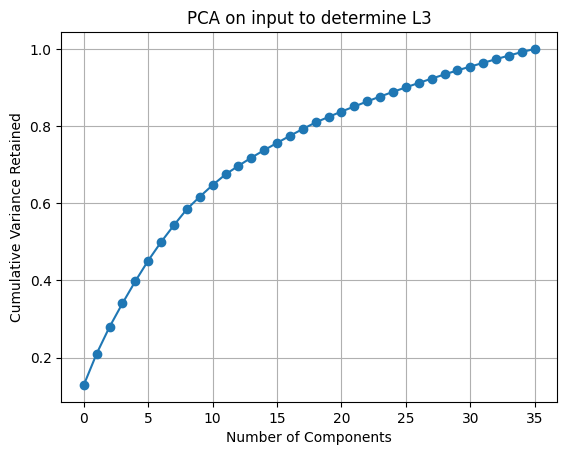

In [75]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy if tensor
input_ul_np = input_ul.cpu().numpy()

# Apply PCA on ORIGINAL INPUT (dimension d = 36)
pca = PCA()
pca.fit(input_ul_np)

# cumulative variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure()
plt.plot(cum_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Retained")
plt.title("PCA on input to determine L3")
plt.grid()
plt.show()

In [76]:
threshold = 0.95   # use 95% variance

L3 = np.argmax(cum_var >= threshold) + 1

print("Selected L3:", L3)

Selected L3: 31


In [77]:
# Define a single autoencoder
class Autoencoder(nn.Module):
    def __init__(self, in1,h1,b1,h2):
        super(Autoencoder, self).__init__()

        # due to alternate linear and non linear layers in 5 layer AANN
        # used linear activation function
        # followed by tanh (non linear) activation function
        self.nl1 = nn.Linear(in1, h1)
        self.bl=nn.Linear(h1,b1)
        self.nl2=nn.Linear(b1,h2)
        self.l=nn.Linear(h2,in1)
        self.tanh = nn.Tanh()

    def encode(self, x):
        x = self.tanh(self.nl1(x))
        x = self.bl(x)
        return x  # Encoded representation

    def forward(self, x):
        x = self.tanh(self.nl1(x))
        x=self.bl(x)
        x = self.tanh(self.nl2(x))
        x=self.l(x)
        return x # x is the output feature vector given by the model

In [78]:
labeled_dataloader = get_dataloader(input_l, target_l, batch_size=75)
target_ul=input_ul
unlabeled_dataloader = get_dataloader(input_ul, target_ul, batch_size=175)


for batch_xl, batch_yl in labeled_dataloader:
    print("Labeled batch features shape:", batch_xl.shape)
    print("Labeled batch labels shape:", batch_yl.shape)
    break

# Check shapes for unlabeled data
for batch_xul in unlabeled_dataloader:
    print("Unlabeled batch features shape:", batch_xul[0].shape)
    break

Labeled batch features shape: torch.Size([75, 36])
Labeled batch labels shape: torch.Size([75, 1])
Unlabeled batch features shape: torch.Size([175, 36])


Pre-train 3 Autoencoders sequentially

In [79]:
# Training function for an autoencoder
def train_autoencoder(x, model, num_epochs=2000, learning_rate=0.0005, threshold = 1e-6):
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    dataloader = get_dataloader(x, x, 175)
    losses = []


    for epoch in tqdm(range(num_epochs)):
        total_loss = 0
        for batch_x, batch_y in dataloader:
            optimizer.zero_grad()
            output = model(batch_x)  # model(x) invokes forward
            loss = loss_fn(output, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)

        # Compute relative error and check early stopping condition
        if epoch > 0:
            relative_error = abs(losses[-1] - losses[-2])
            if relative_error < threshold:
                print(f"Early stopping at epoch {epoch} (relative error < {threshold}")
                break


    return model, losses

In [80]:
import matplotlib.pyplot as plt

 16%|█▌        | 323/2000 [00:14<01:16, 22.04it/s]


Early stopping at epoch 323 (relative error < 1e-06


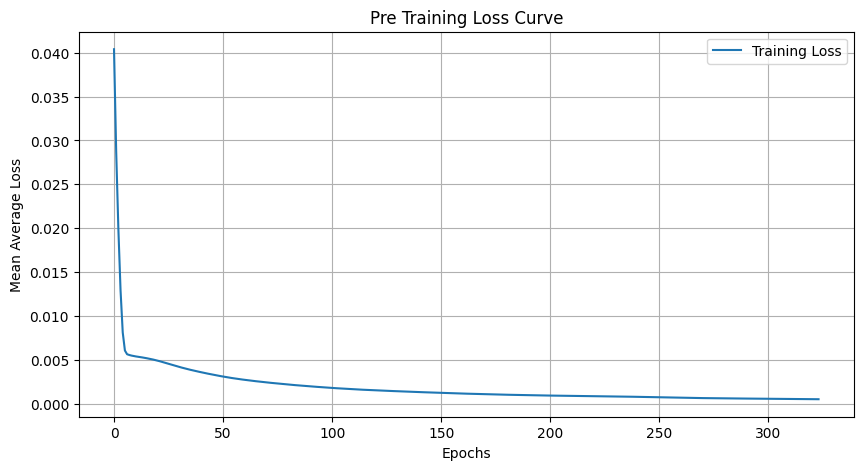

In [81]:
model_1 = Autoencoder(36,35,34,35)
plt.figure(figsize=(10, 5))
model_1, losses_1 = train_autoencoder(input_ul, model_1)

plt.plot(range(len(losses_1)), losses_1, label="Training Loss")

plt.xlabel("Epochs")
plt.ylabel("Mean Average Loss")
plt.title("Pre Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Kashish Agrawal\AppData\Local\Temp\ipykernel_17460\579485626.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x2 = torch.tensor(model_1.encode(input_ul))
 17%|█▋        | 340/2000 [00:15<01:13, 22.61it/s]


Early stopping at epoch 340 (relative error < 1e-06


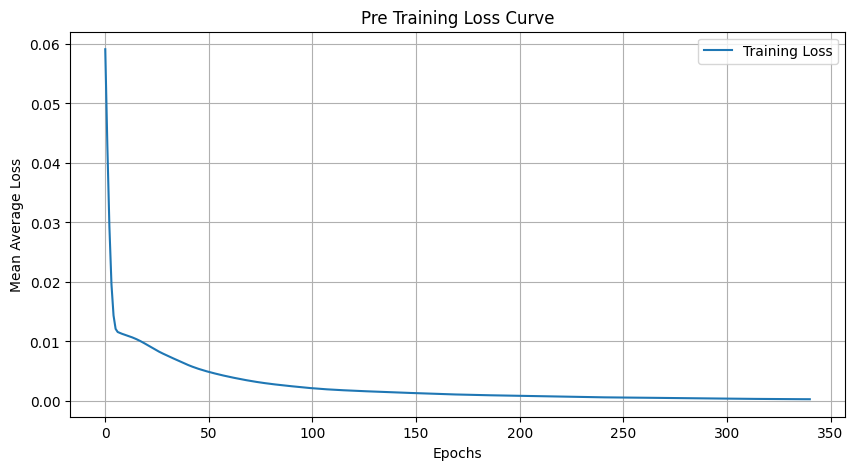

In [82]:
x2 = torch.tensor(model_1.encode(input_ul))
model_2 = Autoencoder(34, 33, 32, 33)
plt.figure(figsize=(10, 5))
model_2, losses_2 = train_autoencoder(x2, model_2)

plt.plot(range(len(losses_2)), losses_2, label="Training Loss")

plt.xlabel("Epochs")
plt.ylabel("Mean Average Loss")
plt.title("Pre Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Kashish Agrawal\AppData\Local\Temp\ipykernel_17460\974611610.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x3 = torch.tensor(model_2.encode(x2))
 16%|█▋        | 329/2000 [00:14<01:13, 22.78it/s]


Early stopping at epoch 329 (relative error < 1e-06


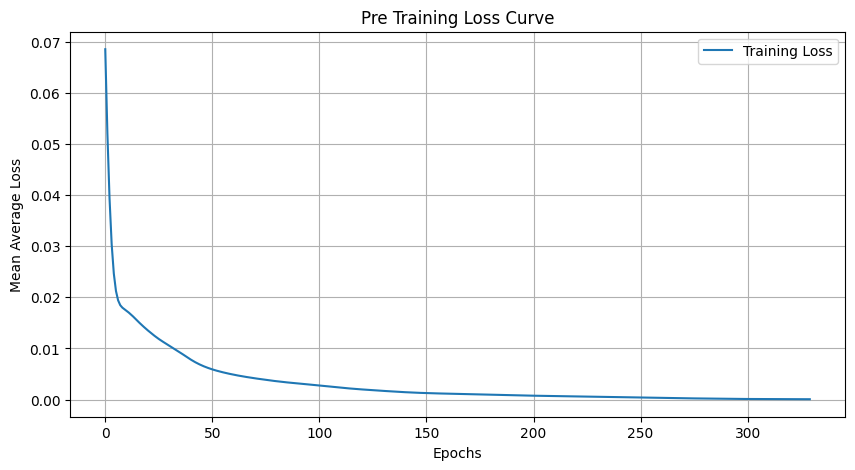

In [83]:
x3 = torch.tensor(model_2.encode(x2))
model_3 = Autoencoder(32, 31, 30 , 31)
plt.figure(figsize=(10, 5))
model_3, losses_3 = train_autoencoder(x3, model_3)

plt.plot(range(len(losses_3)), losses_3, label="Training Loss")

plt.xlabel("Epochs")
plt.ylabel("Mean Average Loss")
plt.title("Pre Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [84]:
# # Define the classifier using the trained encoders
# class DFNN(nn.Module):
#     def __init__(self, ae1, ae2, ae3, b3,  op=5):
#         super(DFNN, self).__init__()

#         # Use pretrained encoders from autoencoders
#         self.encoder1 = copy.deepcopy(ae1.encode)
#         self.encoder2 = copy.deepcopy(ae2.encode)
#         self.encoder3 = copy.deepcopy(ae3.encode)
#         self.fc_o = nn.Linear(b3, op)

#     def forward(self, x):
#         x = self.encoder1(x)
#         x = self.encoder2(x)
#         x = self.encoder3(x)
#         x = self.fc_o(x)
#         return x

class DFNN(nn.Module):
    def __init__(self, ae1, ae2, ae3, op=5):
        super(DFNN, self).__init__()

        # use encoder layers properly
        self.encoder1 = nn.Sequential(
            ae1.nl1,
            ae1.tanh,
            ae1.bl
        )

        self.encoder2 = nn.Sequential(
            ae2.nl1,
            ae2.tanh,
            ae2.bl
        )

        self.encoder3 = nn.Sequential(
            ae3.nl1,
            ae3.tanh,
            ae3.bl
        )

        # classifier input = L3 dimension
        self.fc_o = nn.Linear(ae3.bl.out_features, op)

    def forward(self, x):
        x = self.encoder1(x)
        x = self.encoder2(x)
        x = self.encoder3(x)
        x = self.fc_o(x)
        return x

In [85]:
# stack training for the DFNN
def train_dfnn(input_l, target_l, model_s, num_epochs=2000, learning_rate=0.0003, tol = 5e-7):
    criterion_s = nn.CrossEntropyLoss()
    optimizer_s = optim.Adam(model_s.parameters(), lr=learning_rate)
    dataloader = get_dataloader(input_l, target_l, 75)
    losses_stack = []

    for epoch in tqdm(range(num_epochs), desc="Training DFNN"):
        total_loss = 0
        for batch_x, batch_y in dataloader:
            optimizer_s.zero_grad()
            output = model_s(batch_x)
            loss = criterion_s(output, batch_y.squeeze(1))
            loss.backward()
            optimizer_s.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        losses_stack.append(avg_loss)

        if epoch > 0:
            relative_error = abs(losses_stack[-1] - losses_stack[-2])
            if relative_error < tol:
                print(f"Early stopping at epoch {epoch} (relative error < {tol}")
                break

    return model_s, losses_stack

Training DFNN:  63%|██████▎   | 1262/2000 [00:52<00:30, 24.09it/s]


Early stopping at epoch 1262 (relative error < 5e-07


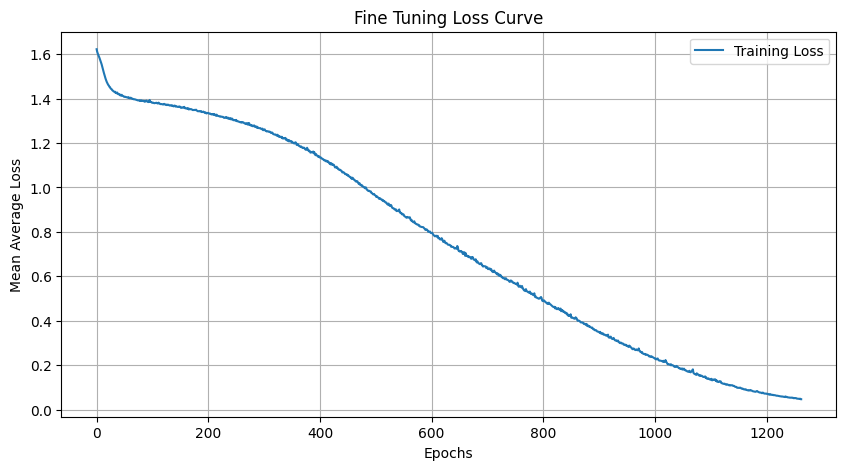

In [86]:
plt.figure(figsize=(10, 5))
model_s = DFNN(model_1, model_2, model_3,  op=5)
model_s, losses_s = train_dfnn(input_l, target_l, model_s)

plt.plot(range(len(losses_s)), losses_s, label="Training Loss")

plt.xlabel("Epochs")
plt.ylabel("Mean Average Loss")
plt.title("Fine Tuning Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

Training DFNN: 100%|██████████| 2000/2000 [01:25<00:00, 23.43it/s]


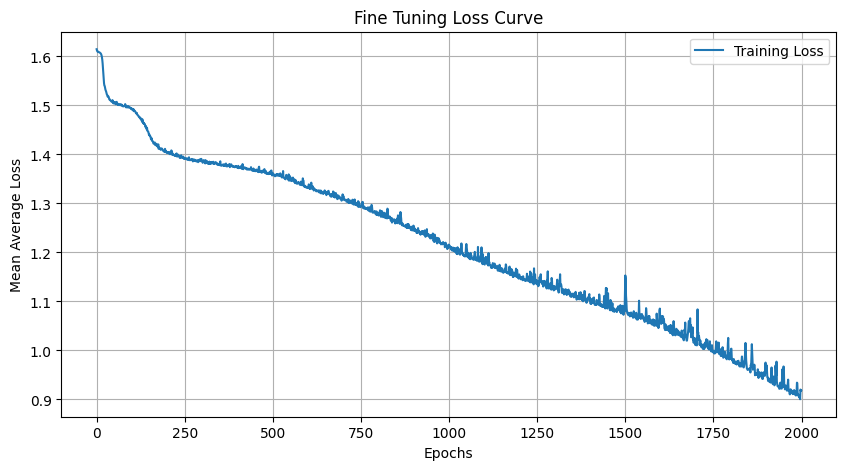

In [87]:
plt.figure(figsize=(10, 5))
model1 = Autoencoder(36,35,34,35)
model2 = Autoencoder(34, 33, 32, 33)
model3 = Autoencoder(32, 31, 30 , 31)
model_no_pre = DFNN(model1, model2, model3, op=5)
model_no_pre, losses_no_pre = train_dfnn(input_l, target_l, model_no_pre)

plt.plot(range(len(losses_no_pre)), losses_no_pre, label="Training Loss")

plt.xlabel("Epochs")
plt.ylabel("Mean Average Loss")
plt.title("Fine Tuning Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

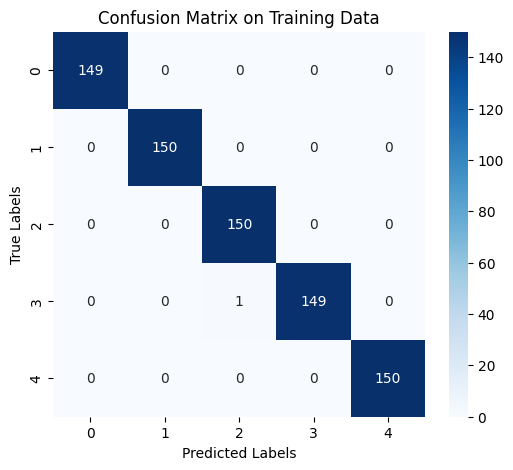

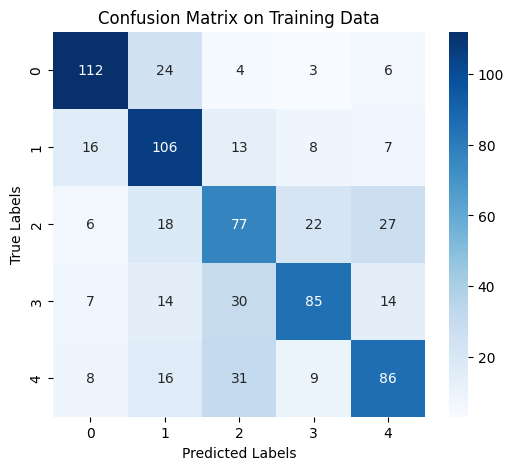

In [88]:
# Function to evaluate the model on test data and plot confusion matrix
def evaluate_model(model, test_features, test_labels):
    model.eval()  # Set model to evaluation mode

    # Get predictions
    with torch.no_grad():
        outputs = model(test_features)  # Forward pass
        predicted_labels = torch.argmax(outputs, dim=1)  # Get class with highest probability

    # Convert test labels to 1D tensor
    test_labels = test_labels.squeeze(1)

    # Compute confusion matrix
    cm = confusion_matrix(test_labels.cpu().numpy(), predicted_labels.cpu().numpy())

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(5), yticklabels=range(5))
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix on Training Data")
    plt.show()

# Run model on test data and plot confusion matrix
evaluate_model(model_s, input_l, target_l)
evaluate_model(model_no_pre, input_l, target_l)

In [89]:
import pandas as pd

base_path = r"C:\Users\Kashish Agrawal\Downloads\FODL_assignment\team19-20260226T071806Z-1-001\team19\task3\\"

# testing input data
inp = pd.read_csv(base_path + "testing_data_set_19_data.csv")
print("testing data:", inp.shape)

# testing labels
oup = pd.read_csv(base_path + "testing_data_set_19_labels.csv")
print("testing labels:", oup.shape)

testing data: (249, 36)
testing labels: (249, 1)


In [90]:
inps = torch.tensor(inp.values, dtype=torch.float32)  # labeled Features
oups = torch.tensor(oup.values, dtype=torch.long)

Test Accuracy: 28.92%


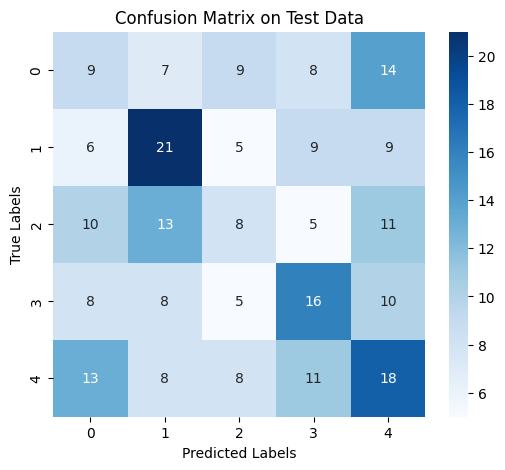

Test Accuracy: 31.73%


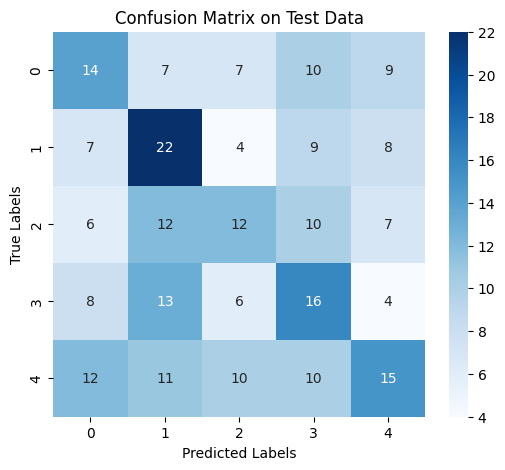

In [91]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score


# Function to evaluate the model on test data and plot confusion matrix
def evaluate_model(model, test_features, test_labels):
    model.eval()  # Set model to evaluation mode

    # Get predictions
    with torch.no_grad():
        outputs = model(test_features)  # Forward pass
        predicted_labels = torch.argmax(outputs, dim=1)  # Get class with highest probability

    # Convert test labels to 1D tensor
    test_labels = test_labels.squeeze(1)

    # Compute accuracy
    acc = accuracy_score(test_labels.cpu().numpy(), predicted_labels.cpu().numpy())
    print(f"Test Accuracy: {acc * 100:.2f}%")

    # Compute confusion matrix
    cm = confusion_matrix(test_labels.cpu().numpy(), predicted_labels.cpu().numpy())

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(5), yticklabels=range(5))
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix on Test Data")
    plt.show()

# Run model on test data and plot confusion matrix
evaluate_model(model_s, inps, oups)
evaluate_model(model_no_pre, inps, oups)